In [95]:
import pandas as pd
import numpy as np

In [96]:
#import data from /Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/processed/ProcessedObservedData.csv
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\ClusteredData.csv')
data = data.sort_values(by=['date'])
data['date'] = pd.to_datetime(data['date'])
data.head(10)

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,cluster,seen
0,818860012482918321,2025-01-01,146.71.50.198,1,2,False,1,1,0.000000,1
2101,818860012482918321,2025-01-01,156.146.63.162,0,2,False,1,1,-1.000000,0
2102,818860012482918321,2025-01-01,46.246.8.77,0,2,False,1,1,-1.000000,0
2103,818860012482918321,2025-01-01,5.79.110.170,0,2,False,1,1,-1.000000,0
2104,818860012482918321,2025-01-01,46.246.8.63,0,2,False,1,1,-1.000000,0
2105,818860012482918321,2025-01-01,46.246.8.91,0,2,False,1,1,-1.000000,0
2106,818860012482918321,2025-01-01,162.0.232.231,0,2,False,1,1,-1.000000,0
2107,818860012482918321,2025-01-01,104.21.54.132,0,2,False,1,1,-1.000000,0
2108,818860012482918321,2025-01-01,46.246.8.131,0,2,False,1,1,-1.000000,0
2109,818860012482918321,2025-01-01,46.246.8.119,0,2,False,1,1,-1.000000,0


In [97]:
# Set up lag features for 'seen'
for lag in [1, 3, 7]:
    data[f'seen_lag_{lag}'] = data.groupby(['API_UserName', 'indicator'])['seen'].shift(lag)

# Rolling features for 'observations'
data['obs_roll_3'] = data.groupby(['API_UserName', 'indicator'])['observations'].transform(
    lambda x: x.shift(1).rolling(window=3).mean()
)
data['obs_roll_7'] = data.groupby(['API_UserName', 'indicator'])['observations'].transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)

# Count of times seen in the last 14 days
data['seen_14day_count'] = data.groupby(['API_UserName', 'indicator'])['seen'].transform(
    lambda x: x.shift(1).rolling(window=14).sum()
)

# Days since last seen
def time_since_last_seen(group):
    last_seen_date = None
    result = []
    for idx, row in group.iterrows():
        if last_seen_date is None:
            result.append(np.nan)
        else:
            delta = (row['date'] - last_seen_date).days
            result.append(delta)
        if row['seen']:
            last_seen_date = row['date']
    return pd.Series(result, index=group.index)

data['days_since_last_seen'] = (
    data.groupby(['indicator'], group_keys=False)
    .apply(time_since_last_seen)
)

C:\Users\jaskew\AppData\Local\Temp\ipykernel_27088\4069898828.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(time_since_last_seen)


In [98]:
data.head(10)

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,cluster,seen,seen_lag_1,seen_lag_3,seen_lag_7,obs_roll_3,obs_roll_7,seen_14day_count,days_since_last_seen
0,818860012482918321,2025-01-01,146.71.50.198,1,2,False,1,1,0.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2101,818860012482918321,2025-01-01,156.146.63.162,0,2,False,1,1,-1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2102,818860012482918321,2025-01-01,46.246.8.77,0,2,False,1,1,-1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2103,818860012482918321,2025-01-01,5.79.110.170,0,2,False,1,1,-1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2104,818860012482918321,2025-01-01,46.246.8.63,0,2,False,1,1,-1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2105,818860012482918321,2025-01-01,46.246.8.91,0,2,False,1,1,-1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2106,818860012482918321,2025-01-01,162.0.232.231,0,2,False,1,1,-1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2107,818860012482918321,2025-01-01,104.21.54.132,0,2,False,1,1,-1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2108,818860012482918321,2025-01-01,46.246.8.131,0,2,False,1,1,-1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2109,818860012482918321,2025-01-01,46.246.8.119,0,2,False,1,1,-1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
# Shift the 'seen' column to create the 7-day-ahead target
data['seen_in_7_days'] = data.groupby(['API_UserName', 'indicator'])['seen'].shift(-7)

# Drop rows with NaN in target or features (common after shifting/rolling)
model_data = data.dropna(subset=[
    'seen_lag_1', 'seen_lag_3', 'seen_lag_7',
    'obs_roll_3', 'obs_roll_7', 'seen_14day_count',
    'days_since_last_seen', 'seen_in_7_days'
]).copy()  # Explicitly create a copy

# Make sure the target is binary (sometimes booleans get turned into floats)
model_data['seen_in_7_days'] = model_data['seen_in_7_days'].astype(int)
model_data.head(10)

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,cluster,seen,seen_lag_1,seen_lag_3,seen_lag_7,obs_roll_3,obs_roll_7,seen_14day_count,days_since_last_seen,seen_in_7_days
209,818860012482918321,2025-01-15,162.142.125.242,3,2,False,15,1,0.000000,1,1.000000,1.000000,1.000000,3.333333,3.000000,13.000000,1.000000,1
212,818860012482918321,2025-01-15,34.160.111.145,25,2,False,15,1,1.000000,1,1.000000,1.000000,1.000000,27.333333,16.857143,12.000000,1.000000,1
213,818860012482918321,2025-01-15,104.21.61.32,6,2,False,15,1,2.000000,1,0.000000,0.000000,1.000000,4.000000,4.285714,6.000000,2.000000,0
215,818860012482918321,2025-01-15,geo.netsupportsoftware.com/location/loca.asp,2,2,False,15,1,0.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,13.000000,0
216,818860012482918321,2025-01-15,79.98.104.4,22,2,False,15,1,1.000000,1,0.000000,0.000000,0.000000,3.333333,1.428571,2.000000,2.000000,0
217,818860012482918321,2025-01-15,46.246.8.5,2,2,False,15,1,0.000000,1,0.000000,1.000000,0.000000,2.000000,0.857143,1.000000,3.000000,0
210,818860012482918321,2025-01-15,162.142.125.255,3,2,False,15,1,0.000000,1,1.000000,0.000000,1.000000,1.666667,1.571429,12.000000,1.000000,1
4566,818860012482918321,2025-01-15,23.26.221.16,0,2,False,15,1,-1.000000,0,0.000000,0.000000,0.000000,1.000000,0.428571,1.000000,2.000000,0
4522,818860012482918321,2025-01-15,23.26.221.27,0,2,False,15,1,-1.000000,0,0.000000,0.000000,1.000000,0.000000,0.714286,2.000000,7.000000,0
4523,818860012482918321,2025-01-15,64.64.112.145,0,2,False,15,1,-1.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,0


In [100]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define features and target
features = [
    'seen', 'seen_lag_1', 'seen_lag_3', 'seen_lag_7',
    'obs_roll_3', 'obs_roll_7', 'seen_14day_count',
    'days_since_last_seen', 'dayofweek', 'is_weekend', 'month',
    'observations', 'cluster'
]
target = 'seen_in_7_days'

X = model_data[features]
y = model_data[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Train the logistic regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
log_reg.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_pred = log_reg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

#print parameters
print("Model Parameters:", log_reg.get_params())

Accuracy: 0.87
              precision    recall  f1-score   support

           0       1.00      0.87      0.93     12212
           1       0.17      0.91      0.29       348

    accuracy                           0.87     12560
   macro avg       0.58      0.89      0.61     12560
weighted avg       0.97      0.87      0.91     12560

Model Parameters: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


<Figure size 800x600 with 0 Axes>

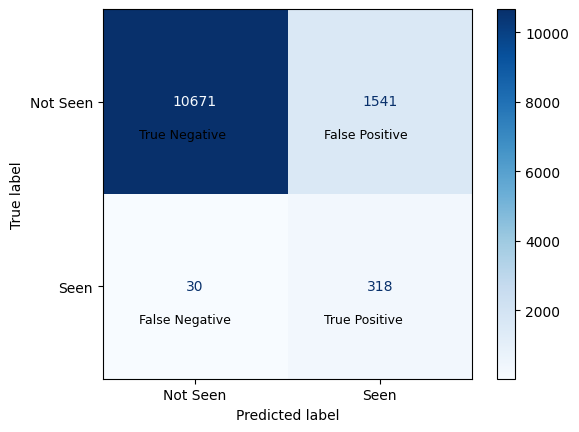

In [101]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt  # Ensure matplotlib is imported for plotting

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Define the actual class labels
class_labels = ['Not Seen', 'Seen']

# Create a ConfusionMatrixDisplay object for visualization
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix, 
    display_labels=class_labels  # Use actual class labels
)

# Plot the confusion matrix with a blue color map for better readability
plt.figure(figsize=(8, 6))  # Adjust the figure size for better visualization
disp.plot(cmap='Blues', values_format='d')  # Use 'd' to display integer values

# Add labels for True Positive, False Positive, True Negative, and False Negative
plt.text(-0.3, 0.2, 'True Negative', fontsize=9, color='black', ha='left')
plt.text(0.7, 0.2, 'False Positive', fontsize=9, color='black', ha='left')
plt.text(-0.3, 1.2, 'False Negative', fontsize=9, color='black', ha='left')
plt.text(0.7, 1.2, 'True Positive', fontsize=9, color='black', ha='left')

# Ensure numbers in the confusion matrix are not displayed in scientific notation
np.set_printoptions(suppress=True)

# Show the plot
plt.show()

In [102]:
# Identify false positives
false_positives = X_test[(y_pred == 1) & (y_test == 0)]

# Print some false positives
false_positives.head(10)

,seen,seen_lag_1,seen_lag_3,seen_lag_7,obs_roll_3,obs_roll_7,seen_14day_count,days_since_last_seen,dayofweek,is_weekend,month,observations,cluster
11684,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.000000,1,False,2,0,-1.000000
14152,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,1,False,3,0,-1.000000
16431,0,0.000000,1.000000,0.000000,2.000000,1.571429,3.000000,3.000000,0,False,3,0,-1.000000
16719,0,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,8.000000,2,False,3,0,-1.000000
16637,0,0.000000,0.000000,0.000000,2.000000,0.857143,2.000000,2.000000,2,False,3,0,-1.000000
19541,0,1.000000,1.000000,0.000000,15.666667,8.142857,8.000000,1.000000,5,True,4,0,-1.000000
1852,1,1.000000,1.000000,1.000000,2.000000,2.000000,13.000000,1.000000,2,False,4,1,0.000000
969,1,1.000000,0.000000,0.000000,8.666667,3.714286,1.000000,1.000000,3,False,2,18,1.000000
14052,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,1,False,3,0,-1.000000
17801,0,0.000000,0.000000,1.000000,0.000000,0.142857,3.000000,7.000000,1,False,4,0,-1.000000


In [103]:
# Identify true positives
true_positives = X_test[(y_pred == 1) & (y_test == 1)]

# Print some true positives
true_positives.head(10)

,seen,seen_lag_1,seen_lag_3,seen_lag_7,obs_roll_3,obs_roll_7,seen_14day_count,days_since_last_seen,dayofweek,is_weekend,month,observations,cluster
10880,0,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,10.000000,3,False,2,0,-1.000000
10325,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0,False,2,0,-1.000000
1220,1,1.000000,1.000000,1.000000,11.333333,13.000000,12.000000,1.000000,0,False,3,11,2.000000
8449,0,0.000000,1.000000,0.000000,3.000000,1.285714,5.000000,3.000000,3,False,2,0,-1.000000
18309,0,1.000000,1.000000,0.000000,12.666667,11.285714,12.000000,1.000000,5,True,4,0,-1.000000
531,1,1.000000,1.000000,1.000000,1.333333,2.428571,8.000000,1.000000,1,False,2,5,0.000000
14124,0,0.000000,1.000000,0.000000,1.000000,0.428571,2.000000,3.000000,1,False,3,0,-1.000000
890,1,0.000000,0.000000,0.000000,0.000000,0.428571,7.000000,4.000000,0,False,2,3,0.000000
273,1,1.000000,1.000000,1.000000,2.333333,2.857143,13.000000,1.000000,5,True,1,3,0.000000
16694,0,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,8.000000,2,False,3,0,-1.000000


In [104]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(log_reg, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')

# Print the cross-validation scores and their mean
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())

Cross-validation scores: [0.91124019 0.91720167 0.91827168 0.91653928 0.91618261]
Mean cross-validation score: 0.9158870885559972


In [105]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [106]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions using the Random Forest model
y_pred_rf = rf.predict(X_test)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Print the evaluation metrics
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print(f"Random Forest Precision: {precision_rf:.2f}")
print(f"Random Forest Recall: {recall_rf:.2f}")
print(f"Random Forest F1 Score: {f1_rf:.2f}")

# Print the classification report
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.95
Random Forest Precision: 0.26
Random Forest Recall: 0.37
Random Forest F1 Score: 0.30

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     12212
           1       0.26      0.37      0.30       348

    accuracy                           0.95     12560
   macro avg       0.62      0.67      0.64     12560
weighted avg       0.96      0.95      0.96     12560



In [107]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42, scale_pos_weight=len(y_train_balanced[y_train_balanced == 0]) / len(y_train_balanced[y_train_balanced == 1]))
xgb.fit(X_train_balanced, y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [108]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions using the XGBoost model
y_pred_xgb = xgb.predict(X_test)

# Calculate evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Print the evaluation metrics
print(f"XGBoost Accuracy: {accuracy_xgb:.2f}")
print(f"XGBoost Precision: {precision_xgb:.2f}")
print(f"XGBoost Recall: {recall_xgb:.2f}")
print(f"XGBoost F1 Score: {f1_xgb:.2f}")

# Print the classification report
print("\nClassification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.93
XGBoost Precision: 0.21
XGBoost Recall: 0.50
XGBoost F1 Score: 0.30

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     12212
           1       0.21      0.50      0.30       348

    accuracy                           0.93     12560
   macro avg       0.60      0.72      0.63     12560
weighted avg       0.96      0.93      0.95     12560

